# 21.1 · Thresholding, deskewing and text regions

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain thresholding, deskewing and text regions using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[07 · Geometric Transformations](../../07-geometric-transformations/README.md), [11 · Morphological Image Processing](../../11-morphological-image-processing/README.md), [13 · Edge and Corner Detection](../../13-edge-and-corner-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Optical character recognition converts an image of text into symbols. A useful pipeline distinguishes text detection, geometric cleanup, recognition and layout reconstruction. Blurring, skew, language and font choices can each break a different stage.

## 2. Intuition

Preprocessing should improve separation of strokes from background without deleting punctuation or joining letters. Estimate skew from text-line orientation or reliable foreground geometry, rotate with controlled interpolation and preserve a copy of the original. Thresholding is appropriate for some documents but can harm colored or textured text.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 21
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
CER=(S+D+I)/N
$$

S is substitutions, D deletions, I insertions and N the number of reference characters. One substitution in a five-character word gives CER=0.2. General CER needs an edit-distance alignment; equal-length position errors are only a restricted case.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
substitutions, deletions, insertions, reference_length = 1, 0, 0, 5
cer = (substitutions + deletions + insertions) / reference_length
assert np.isclose(cer, 0.2)
print(cer)

0.2


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The local lab uses known fixed-spaced glyphs to isolate template recognition. Its positional character error is explicitly narrower than unrestricted edit-distance CER.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def ocr(lesson, seed, amount):
    templates = [glyph(i) for i in range(10)]
    text = "2026"
    image = np.hstack([glyph(char) for char in text])
    if lesson == 1:
        image = cv2.GaussianBlur(image, (3, 3), 0.5 * amount)
    if lesson == 2:
        matrix = cv2.getRotationMatrix2D((60, 20), 3 * amount, 1)
        image = cv2.warpAffine(image, matrix, (120, 40))
    recognized = ""
    scores = []
    for index in range(4):
        patch = image[:, index * 30 : (index + 1) * 30]
        distances = [float(np.mean((patch / 255 - template / 255) ** 2)) for template in templates]
        recognized += str(np.argmin(distances))
        scores.append(min(distances))
    return Result(
        "21 · OCR preprocessing and template recognition",
        {
            "Generated text": image,
            "Thresholded": (image > 100).astype(np.uint8),
            "Digit templates": np.hstack(templates),
        },
        curves={"Character reconstruction error": scores},
        metrics={
            "recognized": recognized,
            "expected": text,
            "character_error_fraction": sum(a != b for a, b in zip(recognized, text)) / len(text),
        },
        notes="Fixed-font, fixed-spacing OCR baseline. It is not Tesseract or a deep OCR model; optional adapters process real documents.",
    )

{
  "recognized": "2026",
  "expected": "2026",
  "character_error_fraction": 0.0
}
Fixed-font, fixed-spacing OCR baseline. It is not Tesseract or a deep OCR model; optional adapters process real documents.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import otsu

display(Code(inspect.getsource(otsu), language="python"))

def otsu(image):
    """Choose the threshold maximizing between-class variance."""
    values = np.asarray(image, dtype=np.uint8)
    hist = np.bincount(values.ravel(), minlength=256).astype(float)
    probabilities = hist / hist.sum()
    weights = probabilities.cumsum()
    means = (probabilities * np.arange(256)).cumsum()
    denom = weights * (1 - weights)
    score = np.divide((means[-1] * weights - means) ** 2, denom, out=np.zeros(256), where=denom > 0)
    threshold = int(np.argmax(score))
    return threshold, values > threshold

## 8. Experiment

Change blur, rotation and character spacing independently. Identify whether errors arise before or during recognition.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "recognized": "2026",
    "expected": "2026",
    "character_error_fraction": 0.0
  },
  "second_seed": {
    "recognized": "2026",
    "expected": "2026",
    "character_error_fraction": 0.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

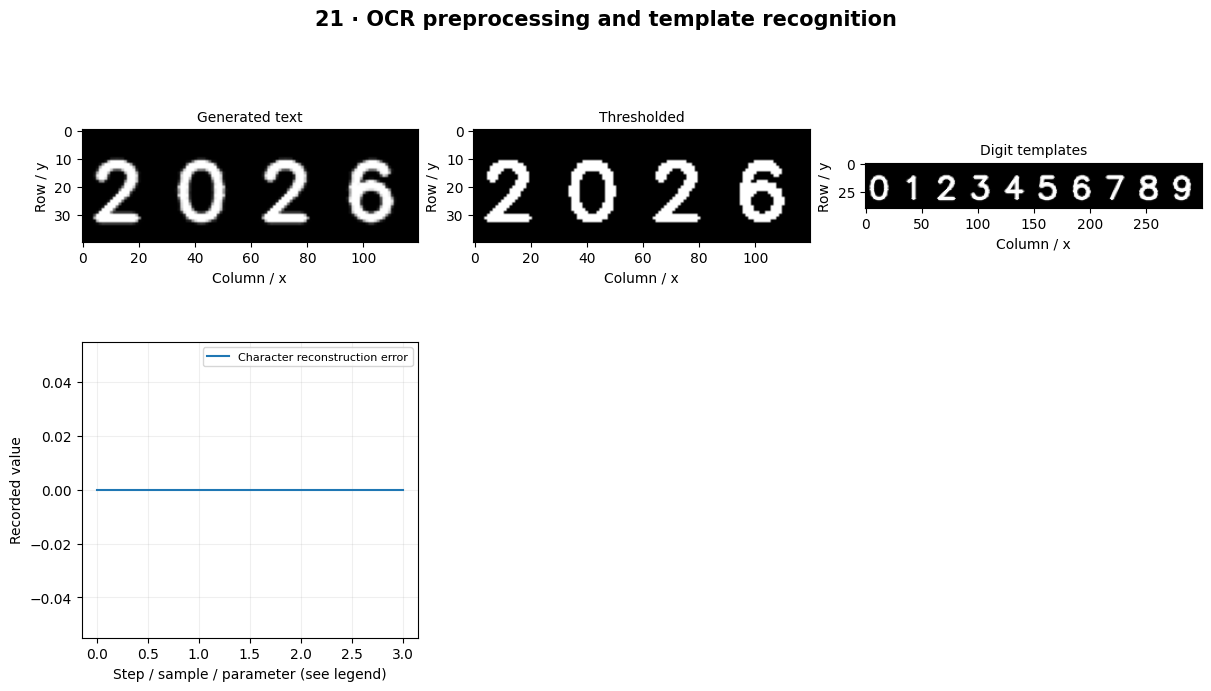

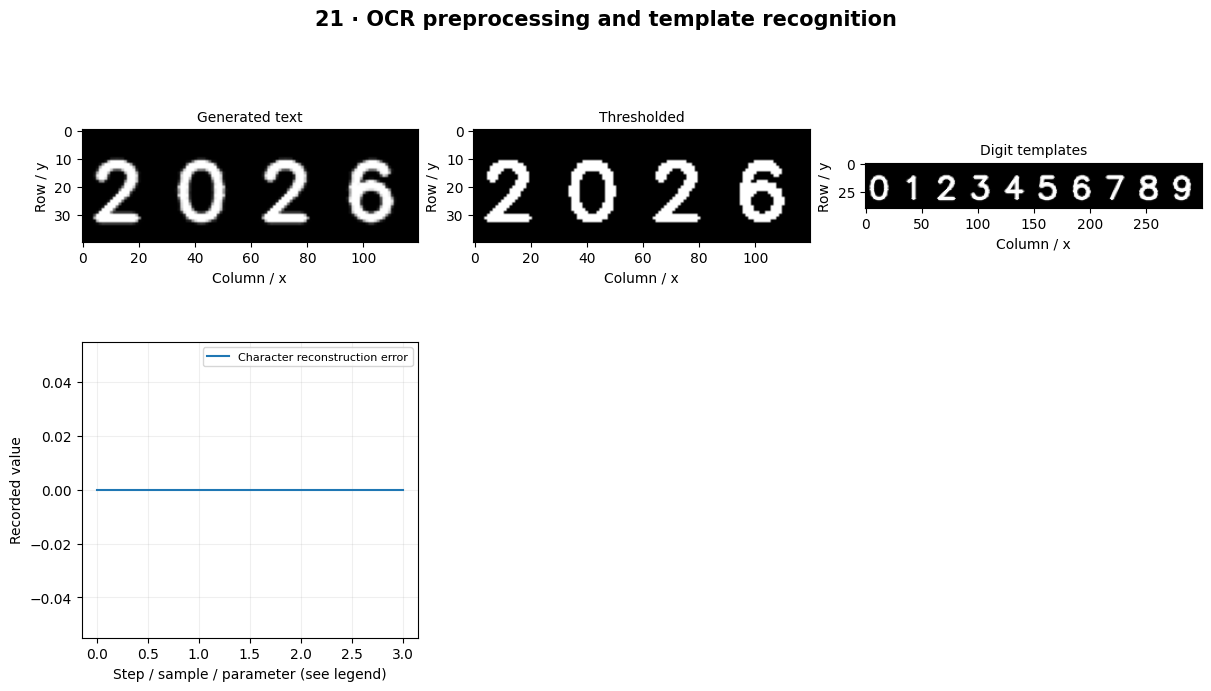

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Document OCR Pipeline**. Extract text while preserving reading order and error evidence. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A higher-resolution resize cannot restore unreadable strokes. OCR confidence is not a guarantee that a number was read correctly.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Change blur, rotation and character spacing independently. Identify whether errors arise before or during recognition.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a document OCR pipeline that retains page coordinates, flags low-confidence fields and evaluates with true edit-distance CER.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Preprocessing should improve separation of strokes from background without deleting punctuation or joining letters. Estimate skew from text-line orientation or reliable foreground geometry, rotate with controlled interpolation and preserve a copy of the original. Thresholding is appropriate for some documents but can harm colored or textured text.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Template recognition and sequence errors** in this chapter.

[Primary reference](https://tesseract-ocr.github.io/tessdoc/ImproveQuality.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)